# Pandas Practice 2

![IRIS, https://github.com/simonava5/fishers-iris-data](./images/iris.png)

After the notebook with a lot of new input, let's start applying it totally by yourselves. 
For this purpose we will use one of the most standard real-life datasets: Its called Iris Dataset, and is all about the plant iris. Let's learn a little bit more about the dataset by looking at it. 

## Learning Objectives





By the end of this notebook, you will feel more comfortable with your newly acquired knowledge, as you will see that you can

- load data from csv files into DataFrames
- access data stored in DataFrames
- use the general functions of a DataFrame to answer questions about the data
- create insightful plots using the pandas function `.plot()`
- explain what conclusions you draw from these visualizations.


In [1]:
# import pandas
import pandas as pd

In [ ]:
# load the data
df = pd.read_csv('data/iris.csv')

Let us first have a look at the head of the table, maybe also on the last 10 rows...

In [3]:
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


How many irises are in the data set?

In [ ]:
df.info() #150 rows, so 150 species

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


How many different species are there?

In [ ]:
print(df['species'].unique())
print(df['species'].nunique())

['Iris-setosa' 'Iris-versicolor' 'Iris-virginica']
3


Calculate the mean, median, mode for petal length

In [ ]:
print(df['petal_length'].mean())
print(df['petal_length'].median())
print(df['petal_length'].mode()) #most frequent value is 1.5 

3.758666666666666
4.35
0    1.5
Name: petal_length, dtype: float64


What can you conclude about the distribution for petal length?

In [ ]:
#there must be a wide distribution of values

What is the smallest and largest value for petal length?

In [36]:
#shortest petal
print(df['petal_length'].sort_values()[:1])
print(df['petal_length'].sort_values(ascending = False)[:1])

22    1.0
Name: petal_length, dtype: float64
118    6.9
Name: petal_length, dtype: float64


Calculate the variance and standard deviation for petal length

In [42]:
print(df['petal_length'].var())
print(df['petal_length'].std())

3.113179418344519
1.7644204199522626


Calculate the basic descriptive statistics for all columns of the iris data set with a single command.

In [44]:
df.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


What is the overall average for sepal length?

In [45]:
print(df['sepal_length'].mean())

5.843333333333334


Use the DataFrame grouping function to determine the count by species.

In [50]:
df.groupby(['species']).count()

,sepal_length,sepal_width,petal_length,petal_width
species,,,,
Iris-setosa,50,50,50,50
Iris-versicolor,50,50,50,50
Iris-virginica,50,50,50,50


Use the DataFrame grouping function to determine the average length and width of sepals and pedals by species.

In [53]:
df.groupby(['species'])[['sepal_length','sepal_width']].mean()

,sepal_length,sepal_width
species,,
Iris-setosa,5.006,3.418
Iris-versicolor,5.936,2.770
Iris-virginica,6.588,2.974


Add the sum of the sepal width and length as a new column to your DataFrame.

In [55]:
df.eval('sum_sepal = sepal_length + sepal_width', inplace = True)
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species,sum_sepal
0,5.1,3.5,1.4,0.2,Iris-setosa,8.6
1,4.9,3.0,1.4,0.2,Iris-setosa,7.9
2,4.7,3.2,1.3,0.2,Iris-setosa,7.9
3,4.6,3.1,1.5,0.2,Iris-setosa,7.7
4,5.0,3.6,1.4,0.2,Iris-setosa,8.6


Visualize petal length with a histogram

Matplotlib is building the font cache; this may take a moment.


<Axes: ylabel='Frequency'>

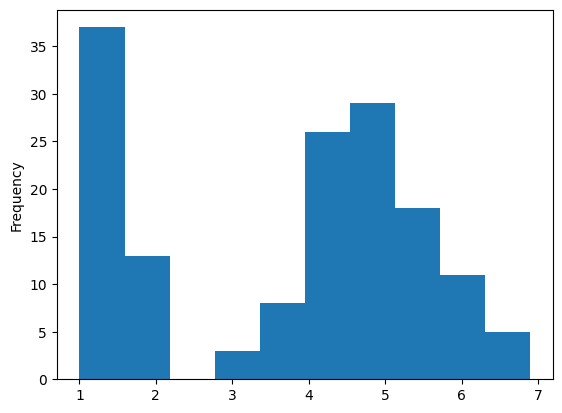

In [57]:
df['petal_length'].plot(kind = "hist")

Describe the distribution

In [ ]:
#there are two peaks of petal lengths, one is at 1 and the other one at 4/5

Which is more informative: the summary statistics or visualizations?

In [ ]:
#the combination of both is best - however, do get an idea of the 
#distribution, the histogram is more informative

Visualize petal length and width with a "scatter_matrix"

<Axes: xlabel='petal_length', ylabel='petal_width'>

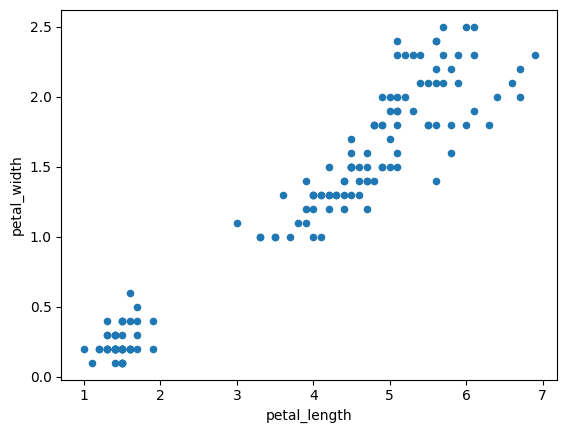

In [ ]:
df.plot(kind = 'scatter', x = "petal_length", y = "petal_width")
#as the petal width increases, so does the petal length. this makes sense, 
#because a larger iris will have wider and longer petals

Create a new column with a rough estimate of petal area by multiplying petal length and width together.

In [60]:
df.eval("petal_area = petal_length*petal_width", inplace=True)
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species,sum_sepal,petal_area
0,5.1,3.5,1.4,0.2,Iris-setosa,8.6,0.28
1,4.9,3.0,1.4,0.2,Iris-setosa,7.9,0.28
2,4.7,3.2,1.3,0.2,Iris-setosa,7.9,0.26
3,4.6,3.1,1.5,0.2,Iris-setosa,7.7,0.30
4,5.0,3.6,1.4,0.2,Iris-setosa,8.6,0.28


Create a new DataFrame with petal areas greater than $1cm^2$.

In [68]:
mask = df['petal_area'] > 1
larger_petals = df[mask]
larger_petals.sort_values('petal_area')

,sepal_length,sepal_width,petal_length,petal_width,species,sum_sepal,petal_area
93,5.0,2.3,3.3,1.0,Iris-versicolor,7.3,3.30
57,4.9,2.4,3.3,1.0,Iris-versicolor,7.3,3.30
98,5.1,2.5,3.0,1.1,Iris-versicolor,7.6,3.30
79,5.7,2.6,3.5,1.0,Iris-versicolor,8.3,3.50
60,5.0,2.0,3.5,1.0,Iris-versicolor,7.0,3.50
...,...,...,...,...,...,...,...
144,6.7,3.3,5.7,2.5,Iris-virginica,10.0,14.25
117,7.7,3.8,6.7,2.2,Iris-virginica,11.5,14.74
100,6.3,3.3,6.0,2.5,Iris-virginica,9.6,15.00
109,7.2,3.6,6.1,2.5,Iris-virginica,10.8,15.25


Create 3 new DataFrames, one for each species. Use the entire dataset.

In [73]:
print(df['species'].unique())

['Iris-setosa' 'Iris-versicolor' 'Iris-virginica']


In [ ]:
mask1= df['species'] == "Iris-setosa"
mask2= df['species'] == 'Iris-versicolor'
mask3= df['species'] == 'Iris-virginica'
df_setosa = df[mask1]
df_versicolor = df[mask2]
df_virginica = df[mask3]